# Phishing URL Detection Using Four Machine Learning Models




### Main models
1. Logistic Regression
2. Linear Support Vector Machine (SVM)
3. Random Forest
4. Gradient Boosting



## 1. Import libraries and set configuration


In [ ]:
# Basic libraries
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Data splitting and model tuning
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Save trained model
import joblib

RANDOM_STATE = 42
TARGET = "phishing"

CLASS_LABELS = {
    0: "Legitimate",
    1: "Phishing"
}

# Folders for saved results
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "models"

for folder in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Simple plot style
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


## 2. Load the dataset from Google Drive


In [ ]:
# Mount Google Drive in Google Colab
from google.colab import drive
drive.mount("/content/drive")

# Dataset path
DATA_PATH = Path("/content/drive/MyDrive/web-page-phishing.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Upload web-page-phishing.csv to MyDrive and run this cell again."
    )

# Read the CSV file
df_raw = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

display(df_raw.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully.
Rows: 100077
Columns: 20


,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
0,37,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,77,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2,126,4,1,2,0,1,3,0,2,0,0,0,0,0,0,0,0,0,1,1
3,18,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,55,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


## 3. Basic data-quality checks


In [ ]:
# Check the columns
print("Columns:")
print(df_raw.columns.tolist())

# Check data types
print("\nData types:")
display(df_raw.dtypes.to_frame("Data type"))

# Check target values
if TARGET not in df_raw.columns:
    raise ValueError(f"Target column '{TARGET}' is missing.")

print("\nTarget values:", sorted(df_raw[TARGET].dropna().unique()))

# Select feature columns
feature_cols = [col for col in df_raw.columns if col != TARGET]

print("\nNumber of features:", len(feature_cols))
print("Feature columns:")
print(feature_cols)

# Check missing values
missing_values = pd.DataFrame({
    "Missing count": df_raw.isna().sum(),
    "Missing %": (df_raw.isna().mean() * 100).round(2)
})

print("\nMissing values:")
display(missing_values)

# Check exact repeated feature-label records
duplicate_count = df_raw.duplicated().sum()
duplicate_percent = duplicate_count / len(df_raw) * 100

print(f"Exact repeated rows: {duplicate_count:,}")
print(f"Exact repeated rows (%): {duplicate_percent:.2f}%")

# Inspect unusual negative values, if present
negative_counts = (df_raw[feature_cols] < 0).sum()
negative_counts = negative_counts[negative_counts > 0]

print("\nFeatures containing negative values:")
display(negative_counts.to_frame("Negative value count"))


Columns:
['url_length', 'n_dots', 'n_hypens', 'n_underline', 'n_slash', 'n_questionmark', 'n_equal', 'n_at', 'n_and', 'n_exclamation', 'n_space', 'n_tilde', 'n_comma', 'n_plus', 'n_asterisk', 'n_hastag', 'n_dollar', 'n_percent', 'n_redirection', 'phishing']

Data types:


,Data type
url_length,int64
n_dots,int64
n_hypens,int64
n_underline,int64
n_slash,int64
n_questionmark,int64
n_equal,int64
n_at,int64
n_and,int64
n_exclamation,int64



Target values: [np.int64(0), np.int64(1)]

Number of features: 19
Feature columns:
['url_length', 'n_dots', 'n_hypens', 'n_underline', 'n_slash', 'n_questionmark', 'n_equal', 'n_at', 'n_and', 'n_exclamation', 'n_space', 'n_tilde', 'n_comma', 'n_plus', 'n_asterisk', 'n_hastag', 'n_dollar', 'n_percent', 'n_redirection']

Missing values:


,Missing count,Missing %
url_length,0,0.0
n_dots,0,0.0
n_hypens,0,0.0
n_underline,0,0.0
n_slash,0,0.0
n_questionmark,0,0.0
n_equal,0,0.0
n_at,0,0.0
n_and,0,0.0
n_exclamation,0,0.0


Exact repeated rows: 78,186
Exact repeated rows (%): 78.13%

Features containing negative values:


,Negative value count
n_redirection,6949


## 4. Examine the effect of removing exact repeated records




In [ ]:
# Class counts before duplicate removal
before_counts = df_raw[TARGET].value_counts().sort_index()

# Remove exact repeated feature-label records
df = df_raw.drop_duplicates().reset_index(drop=True)

# Class counts after duplicate removal
after_counts = df[TARGET].value_counts().sort_index()

duplicate_effect = pd.DataFrame({
    "Class": ["Legitimate", "Phishing"],
    "Before": [before_counts.get(0, 0), before_counts.get(1, 0)],
    "After": [after_counts.get(0, 0), after_counts.get(1, 0)]
})

duplicate_effect["Before %"] = (
    duplicate_effect["Before"] / duplicate_effect["Before"].sum() * 100
).round(2)

duplicate_effect["After %"] = (
    duplicate_effect["After"] / duplicate_effect["After"].sum() * 100
).round(2)

print(f"Rows before removal: {len(df_raw):,}")
print(f"Rows after removal: {len(df):,}")
print(f"Rows removed: {len(df_raw) - len(df):,}")

display(duplicate_effect)

duplicate_effect.to_csv(
    TABLE_DIR / "duplicate_removal_class_effect.csv",
    index=False
)


Rows before removal: 100,077
Rows after removal: 21,891
Rows removed: 78,186


,Class,Before,After,Before %,After %
0,Legitimate,63715,6019,63.67,27.5
1,Phishing,36362,15872,36.33,72.5


## 5. Exploratory Data Analysis (EDA)


In [ ]:
# Class distribution after preprocessing
class_summary = df[TARGET].value_counts().sort_index().to_frame("Count")
class_summary["Percentage"] = (
    class_summary["Count"] / len(df) * 100
).round(2)
class_summary.index = ["Legitimate", "Phishing"]

print("Class distribution:")
display(class_summary)

# Descriptive statistics
print("Descriptive statistics:")
display(df[feature_cols].describe().T)

# Class-wise feature means
class_means = df.groupby(TARGET)[feature_cols].mean().T
class_means.columns = ["Legitimate mean", "Phishing mean"]
class_means["Difference"] = (
    class_means["Phishing mean"] - class_means["Legitimate mean"]
).abs()

print("Top feature differences between the two classes:")
display(class_means.sort_values("Difference", ascending=False).head(10))


Class distribution:


,Count,Percentage
Legitimate,6019,27.5
Phishing,15872,72.5


Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
url_length,21891.0,78.476086,77.361414,4.0,41.0,61.0,88.0,4165.0
n_dots,21891.0,2.894066,2.161135,1.0,2.0,2.0,3.0,24.0
n_hypens,21891.0,1.308072,2.351815,0.0,0.0,1.0,2.0,43.0
n_underline,21891.0,0.482481,1.385397,0.0,0.0,0.0,0.0,21.0
n_slash,21891.0,2.569184,2.451018,0.0,0.0,2.0,4.0,44.0
n_questionmark,21891.0,0.083642,0.304815,0.0,0.0,0.0,0.0,9.0
n_equal,21891.0,0.710886,1.720661,0.0,0.0,0.0,1.0,23.0
n_at,21891.0,0.083824,0.554197,0.0,0.0,0.0,0.0,43.0
n_and,21891.0,0.492074,1.741748,0.0,0.0,0.0,0.0,26.0
n_exclamation,21891.0,0.009456,0.168437,0.0,0.0,0.0,0.0,10.0


Top feature differences between the two classes:


,Legitimate mean,Phishing mean,Difference
url_length,52.288254,88.407069,36.118815
n_slash,1.218641,3.081338,1.862697
n_hypens,1.835022,1.108241,0.726782
n_equal,0.193886,0.906943,0.713057
n_dots,2.399568,3.081590,0.682022
n_and,0.094700,0.642767,0.548067
n_redirection,0.673700,0.372669,0.301031
n_underline,0.371823,0.524446,0.152623
n_at,0.000332,0.115486,0.115154
n_percent,0.444924,0.361013,0.083911


### 5.1 class-distribution plot

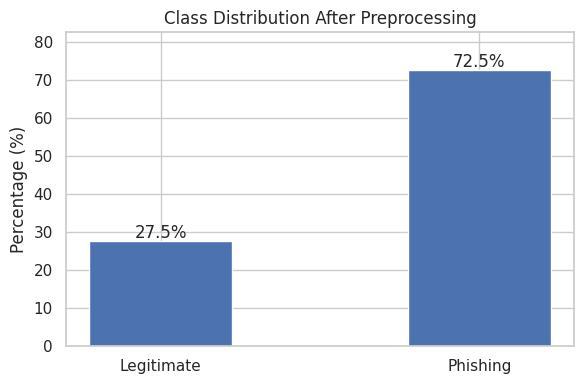

In [ ]:
# Simple class-distribution plot
plot_data = class_summary.reset_index()
plot_data.columns = ["Class", "Count", "Percentage"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    plot_data["Class"],
    plot_data["Percentage"],
    width=0.45
)

ax.set_title("Class Distribution After Preprocessing")
ax.set_ylabel("Percentage (%)")
ax.set_xlabel("")

for bar, value in zip(bars, plot_data["Percentage"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center"
    )

ax.set_ylim(0, max(plot_data["Percentage"]) + 10)
plt.tight_layout()
plt.show()


### 5.2 Correlation of each feature with the target

Top correlations with phishing:


,Correlation
n_slash,0.339327
url_length,0.208464
n_equal,0.185034
n_redirection,-0.142559
n_dots,0.140909
n_and,0.140498
n_hypens,-0.137982
n_questionmark,0.112592
n_at,0.092776
n_underline,0.049189


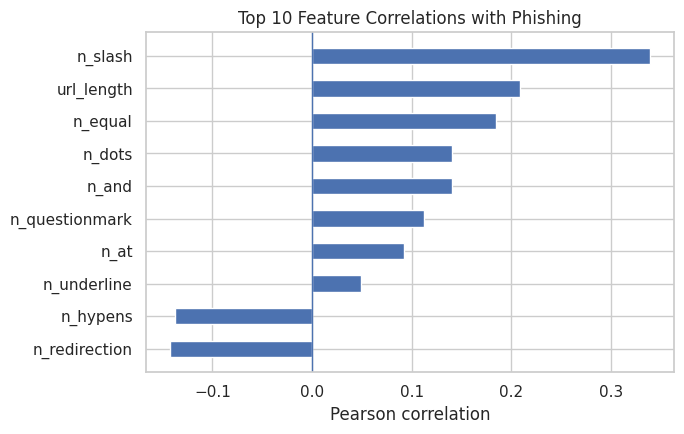

In [ ]:
# Correlation of each feature with the target
correlations = (
    df[feature_cols + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

print("Top correlations with phishing:")
display(correlations.head(10).to_frame("Correlation"))

# Plot the strongest correlations
top_correlations = correlations.head(10).sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(top_correlations.index, top_correlations.values, height=0.5)
ax.axvline(0, linewidth=1)

ax.set_title("Top 10 Feature Correlations with Phishing")
ax.set_xlabel("Pearson correlation")
ax.set_ylabel("")

plt.tight_layout()
plt.show()


### 5.3 Distribution of the strongest features by class

Features selected for distribution analysis:
['n_slash', 'url_length', 'n_equal', 'n_redirection']


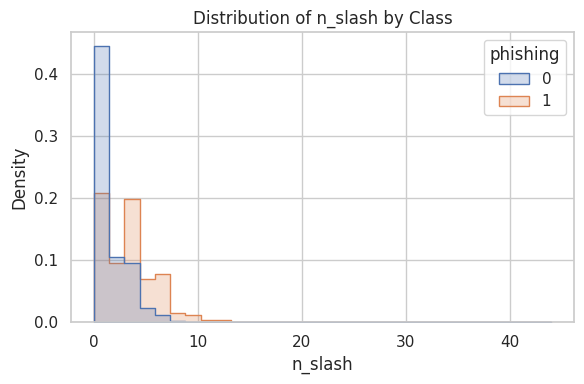

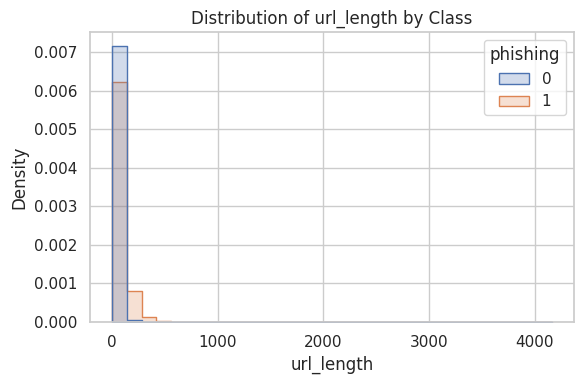

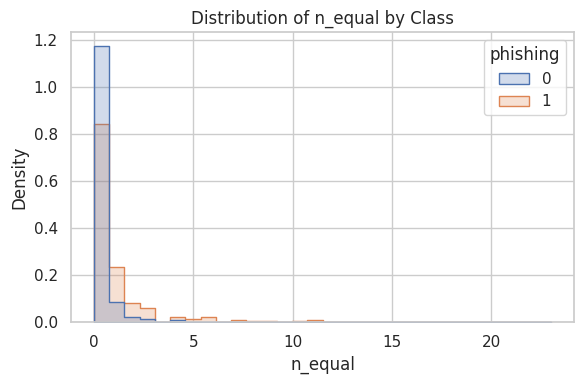

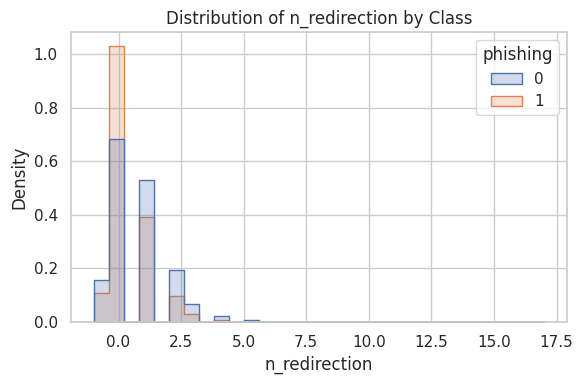

In [ ]:
# Select the four features most strongly related to the target
top_eda_features = (
    correlations.abs()
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

print("Features selected for distribution analysis:")
print(top_eda_features)

for feature in top_eda_features:

    fig, ax = plt.subplots(figsize=(6, 4))

    sns.histplot(
        data=df,
        x=feature,
        hue=TARGET,
        bins=30,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax
    )

    ax.set_title(f"Distribution of {feature} by Class")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")

    plt.tight_layout()
    plt.show()


### 5.4 Zero-value prevalence

Percentage of zero values in each feature:


,Zero values (%)
n_hastag,99.95
n_asterisk,99.71
n_dollar,99.71
n_plus,99.55
n_comma,99.53
n_exclamation,99.37
n_space,98.95
n_tilde,98.94
n_at,92.81
n_percent,92.69


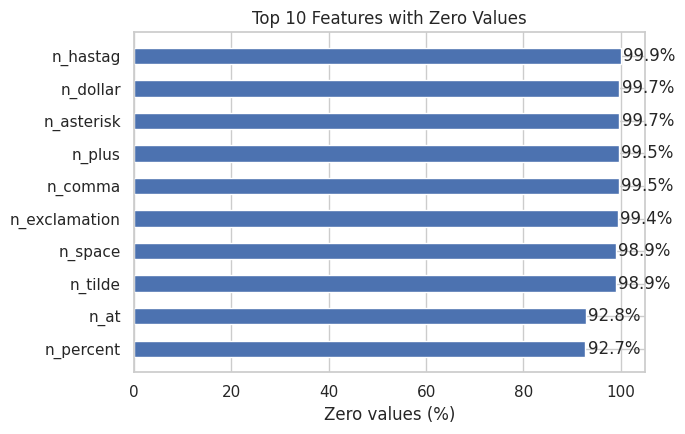

In [ ]:
# Percentage of zero values in every feature
zero_percentage = (
    (df[feature_cols] == 0)
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

zero_table = zero_percentage.to_frame("Zero values (%)")

print("Percentage of zero values in each feature:")
display(zero_table.round(2))

# Plot the 10 features with the most zero values
top_zero = zero_percentage.head(10).sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.barh(
    top_zero.index,
    top_zero.values,
    height=0.5
)

ax.set_title("Top 10 Features with Zero Values")
ax.set_xlabel("Zero values (%)")
ax.set_ylabel("")

for bar, value in zip(bars, top_zero.values):
    ax.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()


### 5.5 IQR outlier summary

In [ ]:
# Count possible outliers using the IQR rule
outlier_rows = []

for feature in feature_cols:

    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outlier_count = (
        (df[feature] < lower_limit) |
        (df[feature] > upper_limit)
    ).sum()

    outlier_rows.append({
        "Feature": feature,
        "Outlier count": int(outlier_count),
        "Outlier %": outlier_count / len(df) * 100
    })

outlier_summary = (
    pd.DataFrame(outlier_rows)
    .sort_values("Outlier %", ascending=False)
    .reset_index(drop=True)
)

print("Features with the highest IQR outlier percentages:")
display(outlier_summary.head(10).round(2))


Features with the highest IQR outlier percentages:


,Feature,Outlier count,Outlier %
0,n_underline,4949,22.61
1,n_and,3075,14.05
2,n_dots,2359,10.78
3,n_equal,1958,8.94
4,url_length,1858,8.49
5,n_questionmark,1732,7.91
6,n_percent,1601,7.31
7,n_at,1574,7.19
8,n_hypens,1193,5.45
9,n_redirection,756,3.45


### 5.6 Correlation heatmap of the strongest features

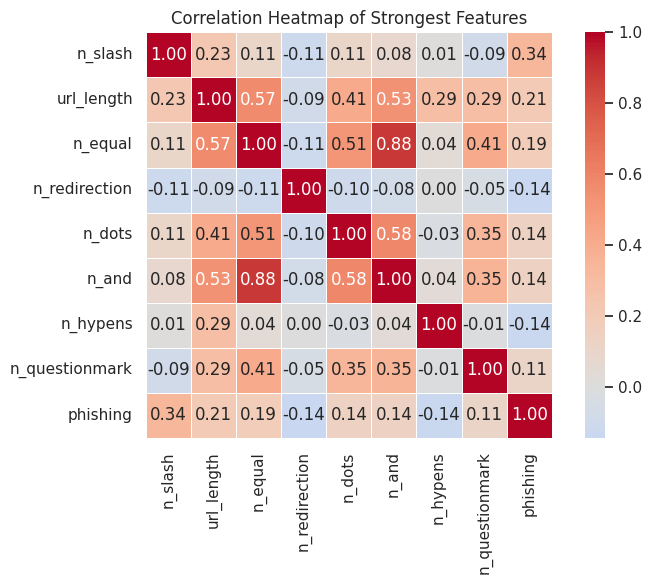

In [ ]:
# Select the 8 features with the strongest absolute target correlations
heatmap_features = (
    correlations.abs()
    .sort_values(ascending=False)
    .head(8)
    .index
    .tolist()
)

heatmap_data = df[heatmap_features + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Correlation Heatmap of Strongest Features")

plt.tight_layout()
plt.show()


## 6. Prepare training and test data





In [ ]:
# Features and target
X = df[feature_cols]
y = df[TARGET]

# 80% training data and 20% test data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

# Check class proportions
split_check = pd.DataFrame({
    "Training %": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    "Test %": (y_test.value_counts(normalize=True).sort_index() * 100).round(2)
})
split_check.index = ["Legitimate", "Phishing"]

display(split_check)

# Five-fold stratified cross-validation for model tuning
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


Training rows: 17512
Test rows: 4379


,Training %,Test %
Legitimate,27.5,27.49
Phishing,72.5,72.51


## 7. Evaluation function




In [ ]:
def get_scores(model, X_data):
    # Probability scores are preferred when available.
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]

    # Linear SVM provides decision scores instead.
    if hasattr(model, "decision_function"):
        return model.decision_function(X_data)

    return model.predict(X_data)


def evaluate_model(model, model_name, cv_score):
    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Scores used for ROC-AUC and Average Precision
    test_score = get_scores(model, X_test)

    # Macro F1 on training and test data
    train_macro_f1 = f1_score(
        y_train,
        train_pred,
        average="macro",
        zero_division=0
    )

    test_macro_f1 = f1_score(
        y_test,
        test_pred,
        average="macro",
        zero_division=0
    )

    return {
        "Model": model_name,
        "CV Macro F1": cv_score,
        "Train Macro F1": train_macro_f1,
        "Test Macro F1": test_macro_f1,
        "Train-Test Gap": train_macro_f1 - test_macro_f1,
        "Accuracy": accuracy_score(y_test, test_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred, zero_division=0),
        "Recall": recall_score(y_test, test_pred, zero_division=0),
        "Phishing F1": f1_score(y_test, test_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, test_score),
        "Average Precision": average_precision_score(y_test, test_score)
    }


### Reusable model evaluation plots




In [ ]:

def plot_model_diagnostics(model, model_name):
    """
    Create three evaluation plots for one trained model:
    1. Confusion Matrix
    2. ROC Curve
    3. Precision-Recall Curve
    """

    # Test-set predictions
    test_pred = model.predict(X_test)

    # Probability or decision scores for ROC and PR curves
    test_score = get_scores(model, X_test)

    # ----------------------------------------------------------
    # 1. Confusion Matrix
    # ----------------------------------------------------------
    cm = confusion_matrix(
        y_test,
        test_pred
    )

    fig, ax = plt.subplots(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(f"Confusion Matrix — {model_name}")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.set_xticklabels(["Legitimate", "Phishing"])
    ax.set_yticklabels(["Legitimate", "Phishing"], rotation=0)

    plt.tight_layout()
    plt.show()

    # ----------------------------------------------------------
    # 2. ROC Curve
    # ----------------------------------------------------------
    fpr, tpr, _ = roc_curve(
        y_test,
        test_score
    )

    roc_auc = roc_auc_score(
        y_test,
        test_score
    )

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"ROC-AUC = {roc_auc:.3f}"
    )

    # Random-classifier reference line
    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    ax.set_title(f"ROC Curve — {model_name}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()

    plt.tight_layout()
    plt.show()

    # ----------------------------------------------------------
    # 3. Precision-Recall Curve
    # ----------------------------------------------------------
    precision_values, recall_values, _ = precision_recall_curve(
        y_test,
        test_score
    )

    average_precision = average_precision_score(
        y_test,
        test_score
    )

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(
        recall_values,
        precision_values,
        linewidth=2,
        label=f"Average Precision = {average_precision:.3f}"
    )

    ax.set_title(f"Precision–Recall Curve — {model_name}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()

    plt.tight_layout()
    plt.show()


## 8. Model 1 — Logistic Regression




In [ ]:
# MODEL 1: LOGISTIC REGRESSION

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

# Small and easy-to-explain tuning grid
logistic_params = {
    "model__C": [0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

logistic_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_params,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

logistic_search.fit(X_train, y_train)

logistic_model = logistic_search.best_estimator_
logistic_result = evaluate_model(
    logistic_model,
    "Logistic Regression",
    logistic_search.best_score_
)

print("Best parameters:", logistic_search.best_params_)
display(pd.DataFrame([logistic_result]).round(4))


Best parameters: {'model__C': 10, 'model__class_weight': 'balanced'}


,Model,CV Macro F1,Train Macro F1,Test Macro F1,Train-Test Gap,Accuracy,Balanced Accuracy,Precision,Recall,Phishing F1,ROC-AUC,Average Precision
0,Logistic Regression,0.7076,0.7074,0.7163,-0.0089,0.7397,0.7656,0.9134,0.708,0.7977,0.8351,0.9364


### Logistic Regression parameter validation



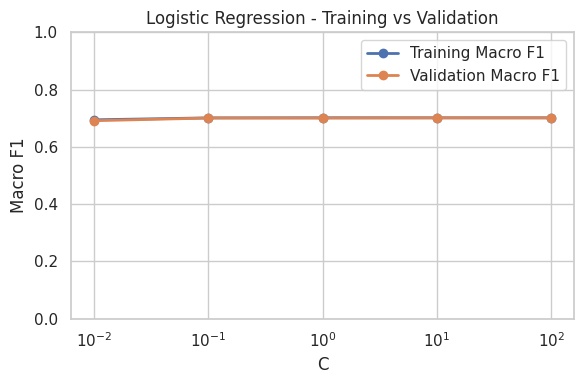

In [ ]:
# Logistic Regression - Training vs Validation by C

c_values = [0.01, 0.1, 1, 10, 100]

train_scores, validation_scores = validation_curve(
    estimator=logistic_pipeline,
    X=X_train,
    y=y_train,
    param_name="model__C",
    param_range=c_values,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    c_values,
    train_mean,
    marker="o",
    linewidth=2,
    label="Training Macro F1"
)

ax.plot(
    c_values,
    validation_mean,
    marker="o",
    linewidth=2,
    label="Validation Macro F1"
)

ax.set_xscale("log")
ax.set_title("Logistic Regression - Training vs Validation")
ax.set_xlabel("C")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()


### Model 1 test evaluation plots




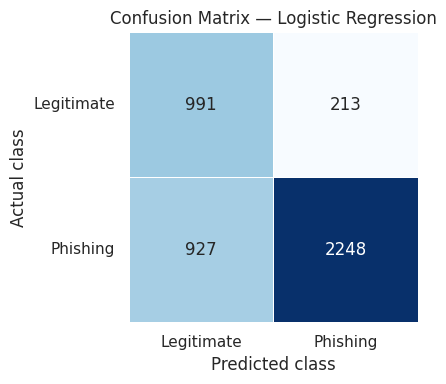

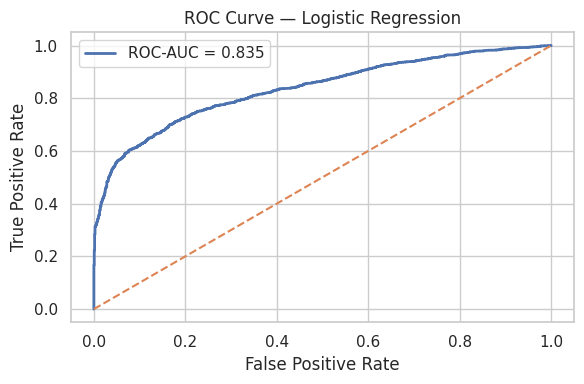

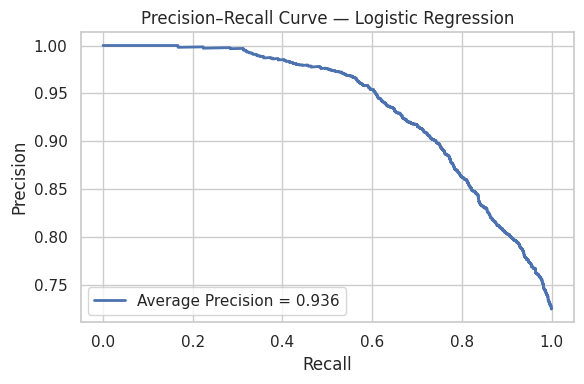

In [ ]:
# Logistic Regression diagnostic plots
plot_model_diagnostics(
    logistic_model,
    "Logistic Regression"
)


## 9. Model 2 — Linear SVM




In [ ]:
# MODEL 2: LINEAR SVM

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearSVC(
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

# Small tuning grid
svm_params = {
    "model__C": [0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

svm_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_params,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

svm_search.fit(X_train, y_train)

svm_model = svm_search.best_estimator_
svm_result = evaluate_model(
    svm_model,
    "Linear SVM",
    svm_search.best_score_
)

print("Best parameters:", svm_search.best_params_)
display(pd.DataFrame([svm_result]).round(4))


Best parameters: {'model__C': 1, 'model__class_weight': 'balanced'}


,Model,CV Macro F1,Train Macro F1,Test Macro F1,Train-Test Gap,Accuracy,Balanced Accuracy,Precision,Recall,Phishing F1,ROC-AUC,Average Precision
0,Linear SVM,0.7048,0.7047,0.7086,-0.0039,0.7305,0.7613,0.9148,0.6929,0.7885,0.8344,0.9361


### Linear SVM parameter validation



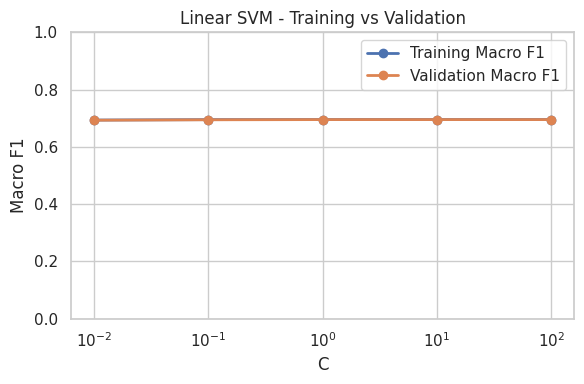

In [ ]:
# Linear SVM - Training vs Validation by C

c_values = [0.01, 0.1, 1, 10, 100]

train_scores, validation_scores = validation_curve(
    estimator=svm_pipeline,
    X=X_train,
    y=y_train,
    param_name="model__C",
    param_range=c_values,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    c_values,
    train_mean,
    marker="o",
    linewidth=2,
    label="Training Macro F1"
)

ax.plot(
    c_values,
    validation_mean,
    marker="o",
    linewidth=2,
    label="Validation Macro F1"
)

ax.set_xscale("log")
ax.set_title("Linear SVM - Training vs Validation")
ax.set_xlabel("C")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()


### Model 2 test evaluation plots



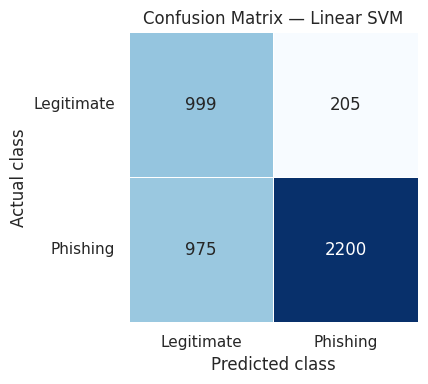

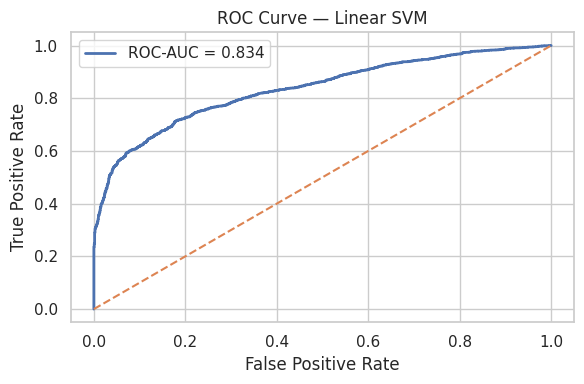

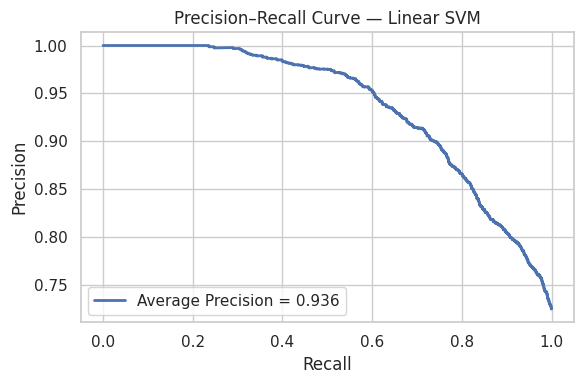

In [ ]:
# Linear SVM diagnostic plots
plot_model_diagnostics(
    svm_model,
    "Linear SVM"
)


## 10. Model 3 — Random Forest




In [ ]:
# MODEL 3: RANDOM FOREST

random_forest = RandomForestClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

# Small tuning grid
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5]
}

rf_search = GridSearchCV(
    estimator=random_forest,
    param_grid=rf_params,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

rf_model = rf_search.best_estimator_
rf_result = evaluate_model(
    rf_model,
    "Random Forest",
    rf_search.best_score_
)

print("Best parameters:", rf_search.best_params_)
display(pd.DataFrame([rf_result]).round(4))


Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


,Model,CV Macro F1,Train Macro F1,Test Macro F1,Train-Test Gap,Accuracy,Balanced Accuracy,Precision,Recall,Phishing F1,ROC-AUC,Average Precision
0,Random Forest,0.7467,0.7633,0.7423,0.021,0.7659,0.7896,0.9249,0.737,0.8203,0.8774,0.9513


### Random Forest parameter validation




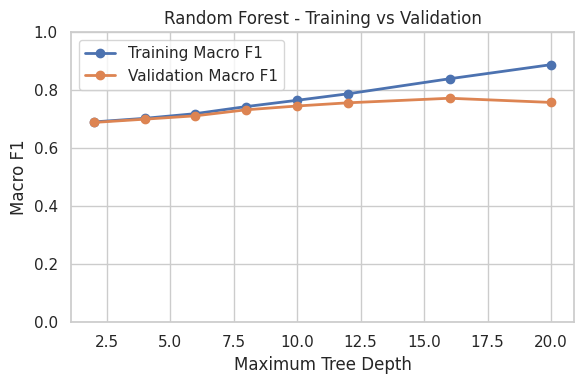

In [ ]:
# Random Forest - Training vs Validation by Maximum Tree Depth

depth_values = [2, 4, 6, 8, 10, 12, 16, 20]

train_scores, validation_scores = validation_curve(
    estimator=random_forest,
    X=X_train,
    y=y_train,
    param_name="max_depth",
    param_range=depth_values,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    depth_values,
    train_mean,
    marker="o",
    linewidth=2,
    label="Training Macro F1"
)

ax.plot(
    depth_values,
    validation_mean,
    marker="o",
    linewidth=2,
    label="Validation Macro F1"
)

ax.set_title("Random Forest - Training vs Validation")
ax.set_xlabel("Maximum Tree Depth")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()


### Model 3 test evaluation plots




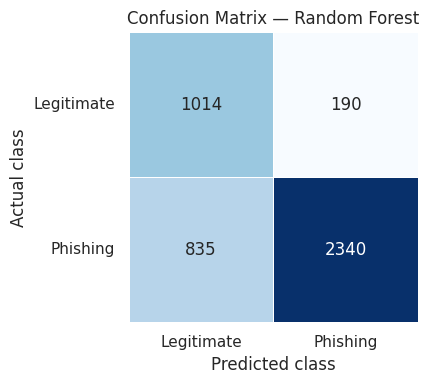

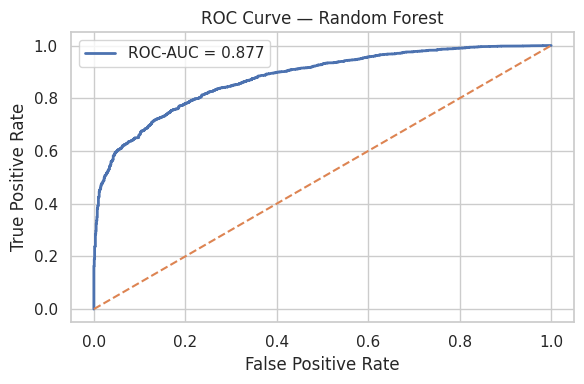

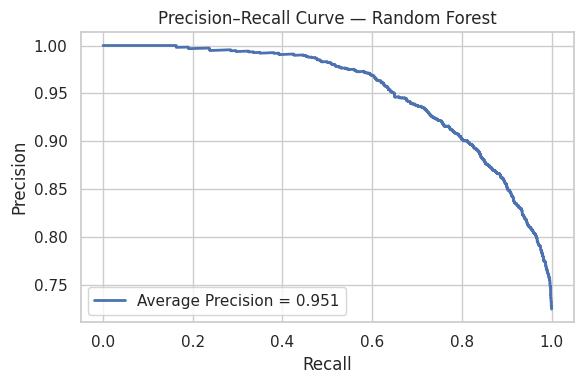

In [ ]:
# Random Forest diagnostic plots
plot_model_diagnostics(
    rf_model,
    "Random Forest"
)


## 11. Model 4 — Gradient Boosting




In [ ]:
# MODEL 4: GRADIENT BOOSTING

gradient_boosting = GradientBoostingClassifier(
    random_state=RANDOM_STATE
)

# Small tuning grid
gb_params = {
    "n_estimators": [80, 120],
    "learning_rate": [0.05, 0.10],
    "max_depth": [2, 3],
    "subsample": [0.8, 1.0]
}

gb_search = GridSearchCV(
    estimator=gradient_boosting,
    param_grid=gb_params,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

gb_model = gb_search.best_estimator_
gb_result = evaluate_model(
    gb_model,
    "Gradient Boosting",
    gb_search.best_score_
)

print("Best parameters:", gb_search.best_params_)
display(pd.DataFrame([gb_result]).round(4))


Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 120, 'subsample': 0.8}


,Model,CV Macro F1,Train Macro F1,Test Macro F1,Train-Test Gap,Accuracy,Balanced Accuracy,Precision,Recall,Phishing F1,ROC-AUC,Average Precision
0,Gradient Boosting,0.7561,0.7632,0.7416,0.0216,0.8107,0.7248,0.8382,0.9156,0.8752,0.8746,0.9502


### Gradient Boosting parameter validation



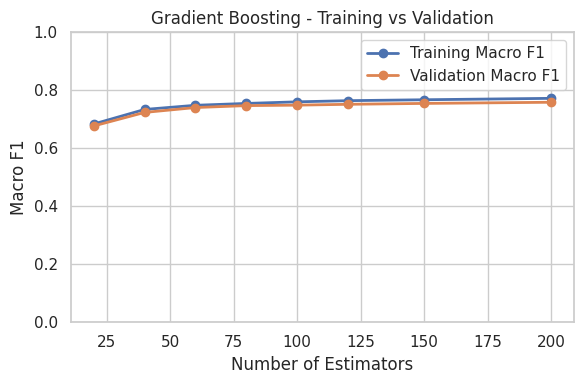

In [ ]:
# Gradient Boosting - Training vs Validation by Number of Estimators

estimator_values = [20, 40, 60, 80, 100, 120, 150, 200]

train_scores, validation_scores = validation_curve(
    estimator=gradient_boosting,
    X=X_train,
    y=y_train,
    param_name="n_estimators",
    param_range=estimator_values,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    estimator_values,
    train_mean,
    marker="o",
    linewidth=2,
    label="Training Macro F1"
)

ax.plot(
    estimator_values,
    validation_mean,
    marker="o",
    linewidth=2,
    label="Validation Macro F1"
)

ax.set_title("Gradient Boosting - Training vs Validation")
ax.set_xlabel("Number of Estimators")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()


### Model 4 test evaluation plots




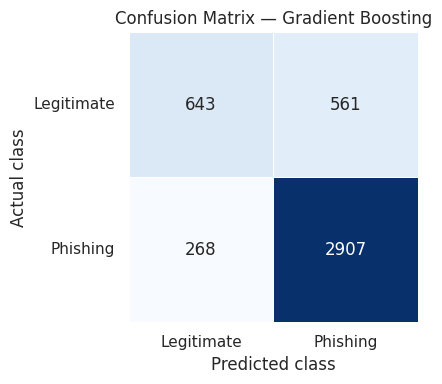

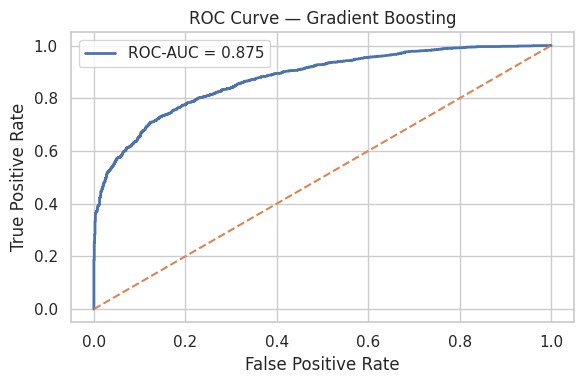

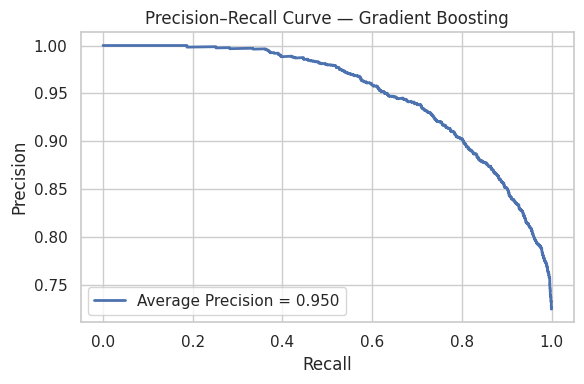

In [ ]:
# Gradient Boosting diagnostic plots
plot_model_diagnostics(
    gb_model,
    "Gradient Boosting"
)


## 12. Compare the four tuned models and check for overfitting




,Model,CV Macro F1,Train Macro F1,Test Macro F1,Train-Test Gap,Accuracy,Balanced Accuracy,Precision,Recall,Phishing F1,ROC-AUC,Average Precision
0,Gradient Boosting,0.7561,0.7632,0.7416,0.0216,0.8107,0.7248,0.8382,0.9156,0.8752,0.8746,0.9502
1,Random Forest,0.7467,0.7633,0.7423,0.0210,0.7659,0.7896,0.9249,0.7370,0.8203,0.8774,0.9513
2,Logistic Regression,0.7076,0.7074,0.7163,-0.0089,0.7397,0.7656,0.9134,0.7080,0.7977,0.8351,0.9364
3,Linear SVM,0.7048,0.7047,0.7086,-0.0039,0.7305,0.7613,0.9148,0.6929,0.7885,0.8344,0.9361


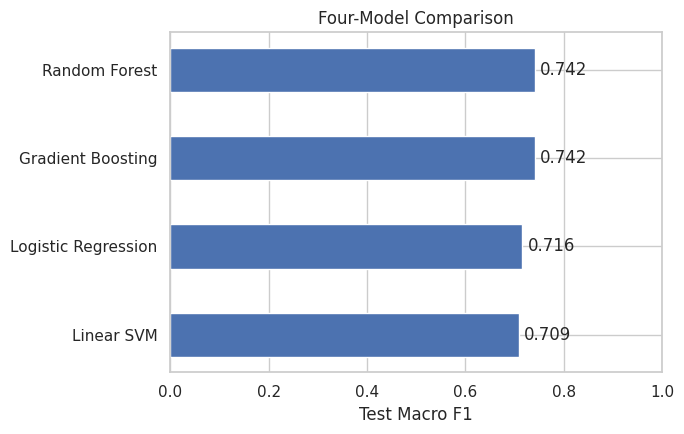

In [ ]:
# Put all four model results into one table
results = pd.DataFrame([
    logistic_result,
    svm_result,
    rf_result,
    gb_result
])

# Sort by cross-validation Macro F1
results = results.sort_values(
    "CV Macro F1",
    ascending=False
).reset_index(drop=True)

results.to_csv(
    TABLE_DIR / "four_tuned_model_comparison.csv",
    index=False
)

display(results.round(4))

# Simple comparison plot using test Macro F1
plot_results = results.sort_values("Test Macro F1")

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.barh(
    plot_results["Model"],
    plot_results["Test Macro F1"],
    height=0.5
)

ax.set_title("Four-Model Comparison")
ax.set_xlabel("Test Macro F1")
ax.set_xlim(0, 1)

for bar, value in zip(bars, plot_results["Test Macro F1"]):
    ax.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()


## 13. Select the final model




In [ ]:
# Store the trained models
model_lookup = {
    "Logistic Regression": logistic_model,
    "Linear SVM": svm_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

# Select the model with the highest CV Macro F1
best_model_name = results.iloc[0]["Model"]
final_model = model_lookup[best_model_name]

print("Final selected model:", best_model_name)

# Final predictions on the untouched test set
final_pred = final_model.predict(X_test)
final_score = get_scores(final_model, X_test)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        final_pred,
        target_names=["Legitimate", "Phishing"],
        digits=4
    )
)


Final selected model: Gradient Boosting

Classification report:
              precision    recall  f1-score   support

  Legitimate     0.7058    0.5341    0.6080      1204
    Phishing     0.8382    0.9156    0.8752      3175

    accuracy                         0.8107      4379
   macro avg     0.7720    0.7248    0.7416      4379
weighted avg     0.8018    0.8107    0.8017      4379



## 14. Feature importance



Top 10 important features:


,Feature,Importance
4,n_slash,0.328359
0,url_length,0.224604
2,n_hypens,0.149588
1,n_dots,0.075666
6,n_equal,0.068732
3,n_underline,0.033189
5,n_questionmark,0.032297
18,n_redirection,0.029788
7,n_at,0.022745
17,n_percent,0.014235


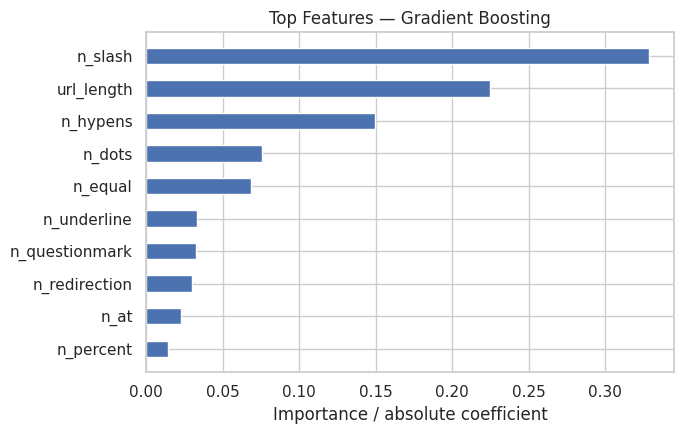

In [ ]:
# Obtain one importance value for each feature
if isinstance(final_model, Pipeline):
    importance_values = np.abs(
        final_model.named_steps["model"].coef_[0]
    )
else:
    importance_values = final_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importance_values
}).sort_values(
    "Importance",
    ascending=False
)

print("Top 10 important features:")
display(importance_df.head(10))

# Plot top 10
top_features = importance_df.head(10).sort_values("Importance")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(
    top_features["Feature"],
    top_features["Importance"],
    height=0.5
)

ax.set_title(f"Top Features — {best_model_name}")
ax.set_xlabel("Importance / absolute coefficient")
ax.set_ylabel("")

plt.tight_layout()
plt.show()
